In [1]:
# ==================================================
# Customer Churn Prediction
# ==================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
# ==================================================
# Load Dataset
# ==================================================

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)

df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ==================================================
# Dataset Overview
# ==================================================

df.info()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


0

In [4]:
# ==================================================
# Missing Values Analysis
# ==================================================

# Check for missing values across all features.
# This helps identify data quality issues that
# may affect model performance.

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Data Cleaning

The `TotalCharges` column is stored as text, so it needs to be converted into a numeric format before modelling.

In [5]:
# ==================================================
# Convert TotalCharges to Numeric
# ==================================================

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after conversion:")
print(df.isnull().sum())

Missing values after conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [6]:
# ==================================================
# Handle Missing Values
# ==================================================

df = df.dropna()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (7032, 21)


In [7]:
# ==================================================
# Remove Unnecessary Column
# ==================================================

df = df.drop(columns=["customerID"])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# ==================================================
# Churn Distribution
# ==================================================

df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

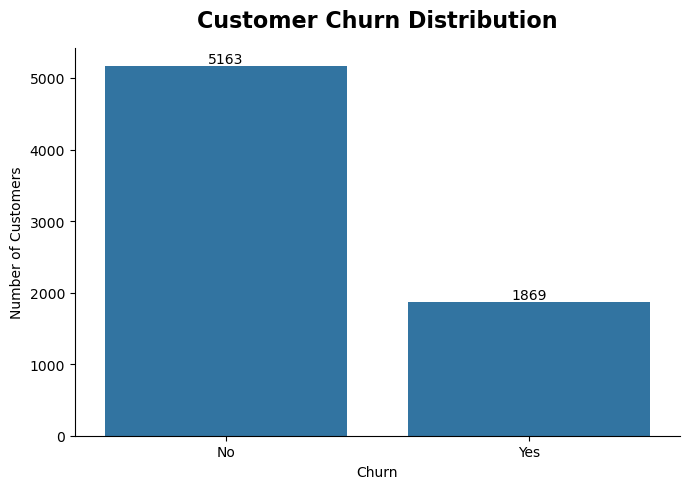

In [9]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x="Churn")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

sns.despine()
plt.tight_layout()

plt.savefig("../images/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Contract Type vs Customer Churn

This analysis investigates the relationship between contract type and customer churn.

Understanding this relationship can help organisations identify customers who may be at a higher risk of leaving.

In [10]:
# ==================================================
# Contract Type vs Churn
# ==================================================

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


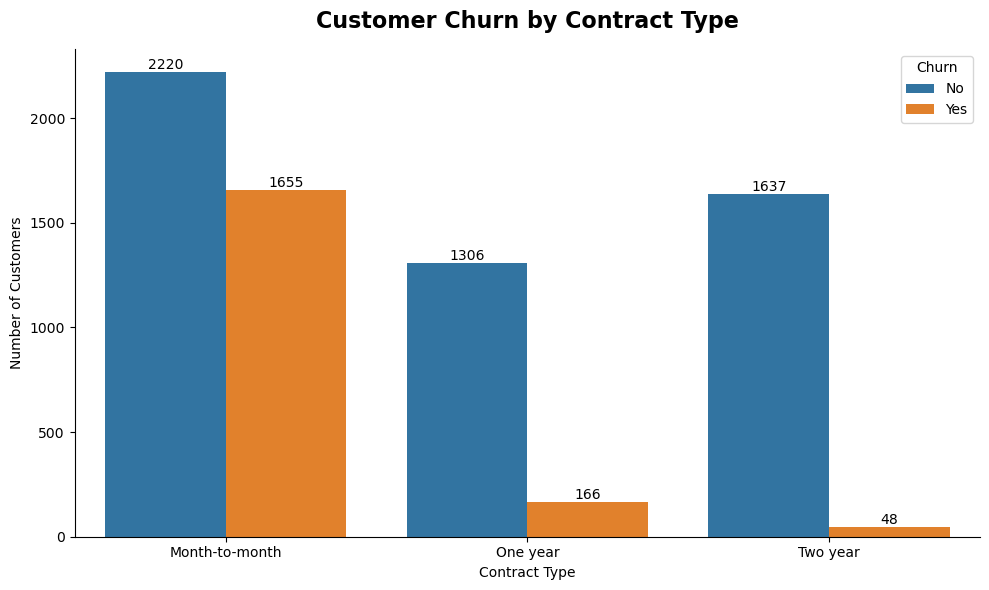

In [11]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Customer Churn by Contract Type",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/contract_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Customers on month-to-month contracts exhibit substantially higher churn rates compared to customers with one-year or two-year contracts.

Longer contracts appear to improve customer retention and reduce churn risk.

# Customer Tenure vs Churn

Customer tenure represents the length of time a customer has remained with the company.

This analysis investigates whether long-term customers are less likely to churn.

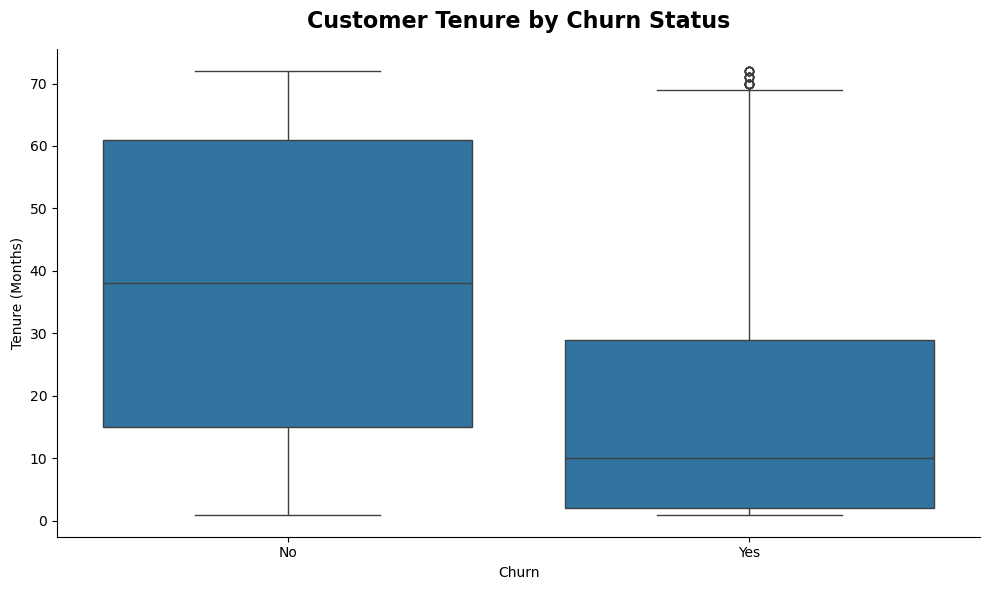

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title(
    "Customer Tenure by Churn Status",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/tenure_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Customers who churn generally have shorter tenures than customers who remain.

Retention efforts may be most effective when targeted at newer customers.

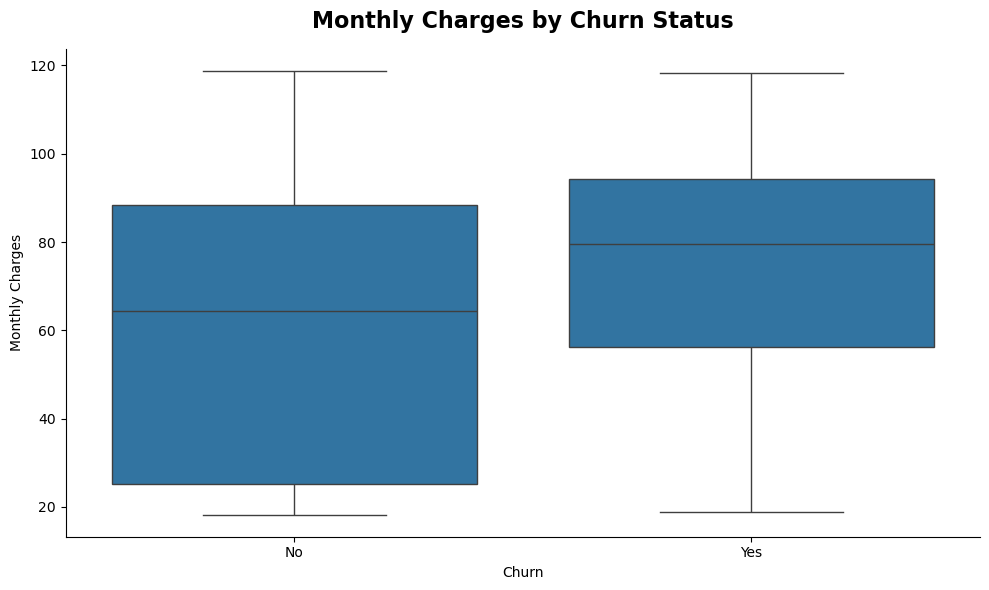

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title(
    "Monthly Charges by Churn Status",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/monthly_charges_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insight

Customers with higher monthly charges tend to exhibit higher churn rates, suggesting that pricing may influence customer retention.

In [14]:
# ==================================================
# Encode Target Variable
# ==================================================

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [15]:
# ==================================================
# Identify Categorical Features
# ==================================================

categorical_cols = df.select_dtypes(
    include="object"
).columns

print(categorical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [16]:
# ==================================================
# Encode Categorical Variables
# ==================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [17]:
# ==================================================
# Define Features and Target
# ==================================================

X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


In [18]:
# ==================================================
# Train Test Split
# ==================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (5625, 19)
Testing Shape: (1407, 19)


In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
# ==================================================
# Logistic Regression Model
# ==================================================

log_model = LogisticRegression(
    max_iter=2000
)

log_model.fit(
    X_train,
    y_train
)

y_pred = log_model.predict(X_test)

In [21]:
# ==================================================
# Model Evaluation
# ==================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred
))

Accuracy: 0.796

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



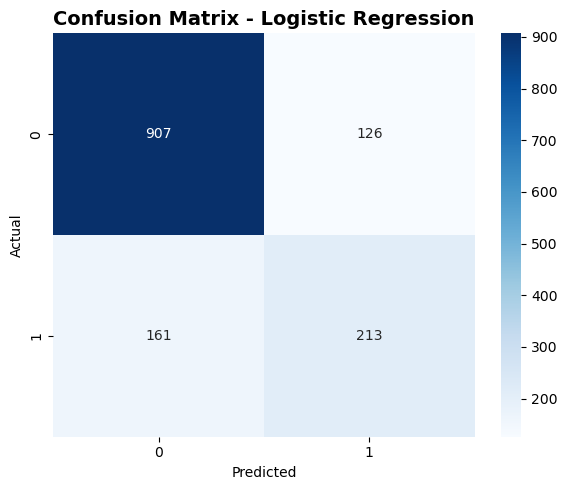

In [22]:
# ==================================================
# Confusion Matrix
# ==================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Logistic Regression",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
# ==================================================
# Random Forest Classifier
# ==================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [25]:
# ==================================================
# Random Forest Evaluation
# ==================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy,4)
)

print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy: 0.7896

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



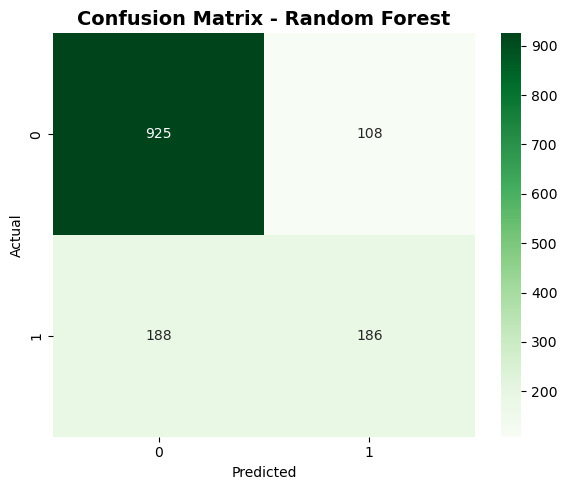

In [26]:
# ==================================================
# Random Forest Confusion Matrix
# ==================================================

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Confusion Matrix - Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../images/rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# ==================================================
# Feature Importance
# ==================================================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(10)
)

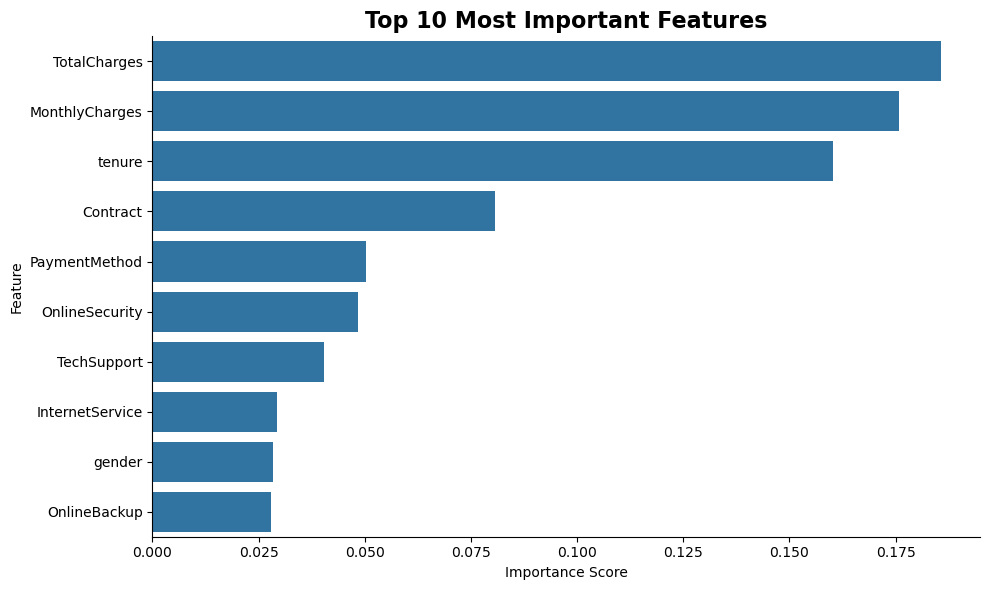

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Most Important Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.796020
1,Random Forest,0.789623


# Executive Summary

The objective of this project was to predict customer churn and identify the key factors contributing to customer attrition.

Two machine learning models were developed and evaluated:

- Logistic Regression
- Random Forest Classifier

Logistic Regression achieved the highest accuracy of 79.6%, slightly outperforming the Random Forest model.

Exploratory analysis revealed several important business insights:

- Customers with month-to-month contracts exhibited significantly higher churn rates.
- Customers with shorter tenure were more likely to leave.
- Higher monthly charges were associated with increased churn.
- Contract type, tenure, monthly charges, and total charges were among the strongest predictors of churn.

These findings suggest that customer retention strategies should focus on newly acquired customers, customers with flexible contracts, and customers facing higher service costs.

# Business Recommendations

## Recommendation 1: Improve Early Customer Retention

Customers with shorter tenure showed the highest churn risk.

Actions:

- Enhanced onboarding programs
- Early engagement campaigns
- Loyalty incentives during the first year

---

## Recommendation 2: Encourage Long Term Contracts

Month-to-month customers demonstrated substantially higher churn rates.

Actions:

- Offer discounts for annual subscriptions
- Introduce contract upgrade promotions

---

## Recommendation 3: Bundle Value Added Services

Online Security and Tech Support emerged as important churn predictors.

Actions:

- Promote service bundles
- Offer discounted security packages

---

## Recommendation 4: Review Pricing Strategy

Higher monthly charges were associated with increased churn.

Actions:

- Evaluate pricing structures
- Introduce flexible pricing options
- Offer targeted retention discounts

In [30]:
from sklearn.metrics import roc_auc_score

log_probs = log_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(
    y_test,
    log_probs
)

print("ROC-AUC Score:", round(roc_auc,4))

ROC-AUC Score: 0.8347


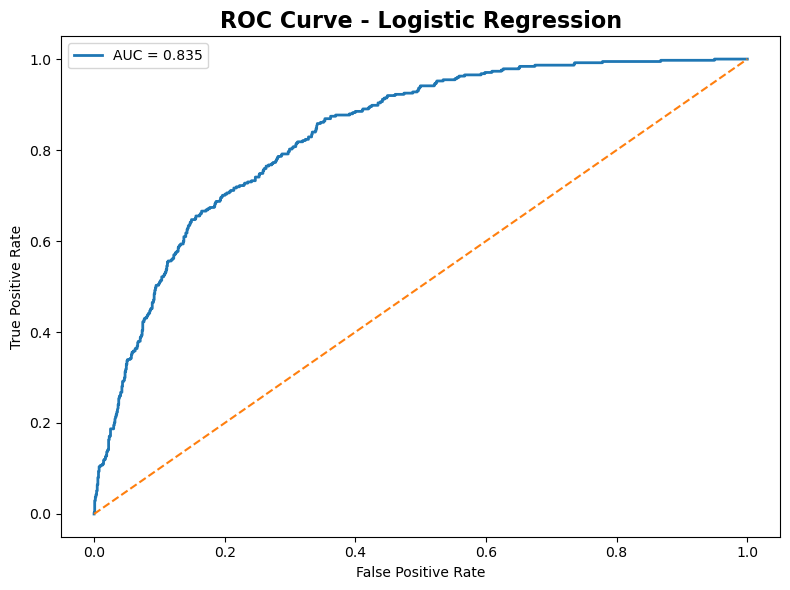

In [31]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    log_probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title(
    "ROC Curve - Logistic Regression",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()

plt.show()